In [7]:
# 首先获得最终shap排序图
import pandas as pd

target_name = 'qf'
# Load the sheets into DataFrames
df_xgboost = pd.read_excel(f'index/{target_name }_index.xlsx', sheet_name=f'{target_name }_xgboost_1-5_shap_importance')
df_rf = pd.read_excel(f'index/{target_name }_index.xlsx', sheet_name=f'{target_name }_rf_1-5_shap_importance')

# Define the weights
weights = {'xgboost': 0.7/5, 'rf': 0.3/5}

# Function to extract model type and apply the corresponding weight
def apply_weight(row):
    model_name = row['Model'].split('_')[0]
    return row['SHAP Value'] * weights[model_name]

# Apply weights to SHAP values based on the model type
df_xgboost['Weighted_SHAP'] = df_xgboost.apply(apply_weight, axis=1)
df_rf['Weighted_SHAP'] = df_rf.apply(apply_weight, axis=1)

# Combine the two DataFrames
df_combined = pd.concat([df_xgboost, df_rf])

# Group by 'Feature Name' and sum the weighted SHAP values
feature_shap = df_combined.groupby('Feature Name')['Weighted_SHAP'].sum().reset_index()

# Sort the features by the summed SHAP values in descending order
feature_shap_sorted = feature_shap.sort_values(by='Weighted_SHAP', ascending=False)

# Save the final feature SHAP values to an Excel file
feature_shap_sorted.to_excel('index/qf_final_feature_shap_values.xlsx',sheet_name = 'qf',index=False)

# Print the top features
print(feature_shap_sorted)


# 首先获得最终shap排序图
import pandas as pd
target_name = 'kl'
# Load the sheets into DataFrames
df_xgboost = pd.read_excel(f'index/{target_name }_index.xlsx', sheet_name=f'{target_name }_xgboost_1-5_shap_importance')
df_rf = pd.read_excel(f'index/{target_name }_index.xlsx', sheet_name=f'{target_name }_rf_1-5_shap_importance')

# Define the weights
weights = {'xgboost': 0.5/5, 'rf': 0.5/5}

# Function to extract model type and apply the corresponding weight
def apply_weight(row):
    model_name = row['Model'].split('_')[0]
    return row['SHAP Value'] * weights[model_name]

# Apply weights to SHAP values based on the model type
df_xgboost['Weighted_SHAP'] = df_xgboost.apply(apply_weight, axis=1)
df_rf['Weighted_SHAP'] = df_rf.apply(apply_weight, axis=1)

# Combine the two DataFrames
df_combined = pd.concat([df_xgboost, df_rf])

# Group by 'Feature Name' and sum the weighted SHAP values
feature_shap = df_combined.groupby('Feature Name')['Weighted_SHAP'].sum().reset_index()

# Sort the features by the summed SHAP values in descending order
feature_shap_sorted = feature_shap.sort_values(by='Weighted_SHAP', ascending=False)

# Save the final feature SHAP values to an Excel file
feature_shap_sorted.to_excel(f'index/{target_name }_final_feature_shap_values.xlsx',sheet_name = 'qf',index=False)

# Print the top features
print(feature_shap_sorted)


                   Feature Name  Weighted_SHAP
20    Calculated Yield Strength      26.009604
44                   Grain Size      16.688005
46                  Habit Plane       8.741485
18    Calculated Grain Boundary       4.043317
54           Interant electrons       3.086639
..                          ...            ...
165  MagpieData mode NfUnfilled       0.000000
164   MagpieData mode NdValence       0.000000
163  MagpieData mode NdUnfilled       0.000000
162    MagpieData mode NValence       0.000000
166   MagpieData mode NfValence       0.000000

[277 rows x 2 columns]
                      Feature Name  Weighted_SHAP
44                      Grain Size      25.107738
46                     Habit Plane       8.672716
20       Calculated Yield Strength       6.484462
115    MagpieData mean GSvolume_pa       5.725880
54              Interant electrons       5.607479
..                             ...            ...
153         MagpieData mode Column       0.000000
152   Magpie

In [8]:
# 指定特征列表和模型的权重

import pandas as pd

# 定义函数来处理文件
def process_shap_file(input_file, output_file, features, weights):
    models = ["rf", "xgboost"]
    indices = range(1, 6)
    
    final_original_df = pd.DataFrame()
    final_shap_df = pd.DataFrame()
    
    # 读取并处理所有index的数据
    for index in indices:
        original_df = None
        combined_shap_values = None
        
        for model in models:
            file_prefix = input_file.split('/')[-1].split('_')[0]
            original_sheet_name = f"{file_prefix}_{model}_original_{index}"
            shap_sheet_name = f"{file_prefix}_{model}_shap_{index}"
            
            # 读取原始数据和SHAP值
            original_temp_df = pd.read_excel(f'{input_file}', sheet_name=original_sheet_name)
            shap_temp_df = pd.read_excel(f'{input_file}', sheet_name=shap_sheet_name)
            
            # 初始化original_df和combined_shap_values
            if original_df is None:
                original_df = original_temp_df[features]
                combined_shap_values = shap_temp_df[features] * weights[model]
            else:
                combined_shap_values += shap_temp_df[features] * weights[model]
        
        # 添加index列到原始数据和加权后的SHAP值
        original_df['index'] = index
        combined_shap_values['index'] = index
        
        # 将结果拼接到final_original_df和final_shap_df
        final_original_df = pd.concat([final_original_df, original_df], ignore_index=True)
        final_shap_df = pd.concat([final_shap_df, combined_shap_values], ignore_index=True)
    
    # 保存最终结果到新的Excel文件的两个sheet中
    with pd.ExcelWriter(f'{output_file}', engine='openpyxl') as writer:
        final_original_df.to_excel(writer, sheet_name='Original_Values', index=False)
        final_shap_df.to_excel(writer, sheet_name='SHAP_Values', index=False)
    
    print(f"Combined SHAP values and original values saved to {output_file}")

# 指定特征列表
features_to_plot= ['MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number',
                      'MagpieData mean Number', 'MagpieData avg_dev Number', 'MagpieData mode Number',
                      'MagpieData minimum MendeleevNumber', 'MagpieData maximum MendeleevNumber',
                      'MagpieData range MendeleevNumber', 'MagpieData mean MendeleevNumber',
                      'MagpieData avg_dev MendeleevNumber', 'MagpieData mode MendeleevNumber',
                      'MagpieData minimum AtomicWeight', 'MagpieData maximum AtomicWeight',
                      'MagpieData range AtomicWeight', 'MagpieData mean AtomicWeight',
                      'MagpieData avg_dev AtomicWeight', 'MagpieData mode AtomicWeight', 'MagpieData mean MeltingT',
                      'MagpieData avg_dev MeltingT', 'MagpieData mode MeltingT', 'MagpieData minimum Column',
                      'MagpieData maximum Column', 'MagpieData range Column', 'MagpieData mean Column',
                      'MagpieData avg_dev Column', 'MagpieData mode Column', 'MagpieData minimum Row',
                      'MagpieData maximum Row', 'MagpieData range Row', 'MagpieData mean Row', 'MagpieData avg_dev Row',
                      'MagpieData mode Row', 'MagpieData minimum CovalentRadius', 'MagpieData maximum CovalentRadius',
                      'MagpieData range CovalentRadius', 'MagpieData mean CovalentRadius',
                      'MagpieData avg_dev CovalentRadius', 'MagpieData mode CovalentRadius',
                      'MagpieData minimum Electronegativity', 'MagpieData maximum Electronegativity',
                      'MagpieData range Electronegativity', 'MagpieData mean Electronegativity',
                      'MagpieData avg_dev Electronegativity', 'MagpieData mode Electronegativity',
                      'MagpieData minimum NsValence', 'MagpieData maximum NsValence', 'MagpieData range NsValence',
                      'MagpieData mean NsValence', 'MagpieData avg_dev NsValence', 'MagpieData mode NsValence',
                      'MagpieData minimum NpValence', 'MagpieData maximum NpValence', 'MagpieData range NpValence',
                      'MagpieData mean NpValence', 'MagpieData avg_dev NpValence', 'MagpieData mode NpValence',
                      'MagpieData minimum NdValence', 'MagpieData maximum NdValence', 'MagpieData range NdValence',
                      'MagpieData mean NdValence', 'MagpieData avg_dev NdValence', 'MagpieData mode NdValence',
                      'MagpieData minimum NfValence', 'MagpieData maximum NfValence', 'MagpieData range NfValence',
                      'MagpieData mean NfValence', 'MagpieData avg_dev NfValence', 'MagpieData mode NfValence',
                      'MagpieData minimum NValence', 'MagpieData maximum NValence', 'MagpieData range NValence',
                      'MagpieData mean NValence', 'MagpieData avg_dev NValence', 'MagpieData mode NValence',
                      'MagpieData minimum NsUnfilled', 'MagpieData maximum NsUnfilled', 'MagpieData range NsUnfilled',
                      'MagpieData mean NsUnfilled', 'MagpieData avg_dev NsUnfilled', 'MagpieData mode NsUnfilled',
                      'MagpieData minimum NpUnfilled', 'MagpieData maximum NpUnfilled', 'MagpieData range NpUnfilled',
                      'MagpieData mean NpUnfilled', 'MagpieData avg_dev NpUnfilled', 'MagpieData mode NpUnfilled',
                      'MagpieData minimum NdUnfilled', 'MagpieData maximum NdUnfilled', 'MagpieData range NdUnfilled',
                      'MagpieData mean NdUnfilled', 'MagpieData avg_dev NdUnfilled', 'MagpieData mode NdUnfilled',
                      'MagpieData minimum NfUnfilled', 'MagpieData maximum NfUnfilled', 'MagpieData range NfUnfilled',
                      'MagpieData mean NfUnfilled', 'MagpieData avg_dev NfUnfilled', 'MagpieData mode NfUnfilled',
                      'MagpieData minimum NUnfilled', 'MagpieData maximum NUnfilled', 'MagpieData range NUnfilled',
                      'MagpieData mean NUnfilled', 'MagpieData avg_dev NUnfilled', 'MagpieData mode NUnfilled',
                      'MagpieData minimum GSvolume_pa', 'MagpieData maximum GSvolume_pa',
                      'MagpieData range GSvolume_pa', 'MagpieData mean GSvolume_pa', 'MagpieData avg_dev GSvolume_pa',
                      'MagpieData mode GSvolume_pa', 'MagpieData minimum GSbandgap', 'MagpieData maximum GSbandgap',
                      'MagpieData range GSbandgap', 'MagpieData mean GSbandgap', 'MagpieData avg_dev GSbandgap',
                      'MagpieData mode GSbandgap', 'MagpieData minimum GSmagmom', 'MagpieData maximum GSmagmom',
                      'MagpieData range GSmagmom', 'MagpieData mean GSmagmom', 'MagpieData avg_dev GSmagmom',
                      'MagpieData mode GSmagmom', 'MagpieData minimum SpaceGroupNumber',
                      'MagpieData maximum SpaceGroupNumber', 'MagpieData range SpaceGroupNumber',
                      'MagpieData mean SpaceGroupNumber', 'MagpieData avg_dev SpaceGroupNumber',
                      'MagpieData mode SpaceGroupNumber', 'Yang delta', 'Yang omega', 'APE mean',
                      'Radii local mismatch', 'Radii gamma', 'Configuration entropy', 'Atomic weight mean',
                      'Total weight', 'Lambda entropy', 'Electronegativity delta', 'Electronegativity local mismatch',
                      'VEC mean', 'Mixing enthalpy', 'Mean cohesive energy', 'Interant electrons',
                      'Interant s electrons', 'Interant p electrons', 'Interant d electrons', 'Interant f electrons',
                      'Shear modulus mean', 'Shear modulus delta', 'Shear modulus local mismatch',
                      'Shear modulus strength model', 'H fraction', 'He fraction', 'Li fraction', 'Be fraction',
                      'B fraction', 'C fraction', 'N fraction', 'O fraction', 'F fraction', 'Ne fraction',
                      'Na fraction', 'Mg fraction', 'Al fraction', 'Si fraction', 'P fraction', 'S fraction',
                      'Cl fraction', 'Ar fraction', 'K fraction', 'Ca fraction', 'Sc fraction', 'Ti fraction',
                      'V fraction', 'Cr fraction', 'Mn fraction', 'Fe fraction', 'Co fraction', 'Ni fraction',
                      'Cu fraction', 'Zn fraction', 'Ga fraction', 'Ge fraction', 'As fraction', 'Se fraction',
                      'Br fraction', 'Kr fraction', 'Rb fraction', 'Sr fraction', 'Y fraction', 'Zr fraction',
                      'Nb fraction', 'Mo fraction', 'Tc fraction', 'Ru fraction', 'Rh fraction', 'Pd fraction',
                      'Ag fraction', 'Cd fraction', 'In fraction', 'Sn fraction', 'Sb fraction', 'Te fraction',
                      'I fraction', 'Xe fraction', 'Cs fraction', 'Ba fraction', 'La fraction', 'Ce fraction',
                      'Pr fraction', 'Nd fraction', 'Pm fraction', 'Sm fraction', 'Eu fraction', 'Gd fraction',
                      'Tb fraction', 'Dy fraction', 'Ho fraction', 'Er fraction', 'Tm fraction', 'Yb fraction',
                      'Lu fraction', 'Hf fraction', 'Ta fraction', 'W fraction', 'Re fraction', 'Os fraction',
                      'Ir fraction', 'Pt fraction', 'Au fraction', 'Hg fraction', 'Tl fraction', 'Pb fraction',
                      'Bi fraction', 'Po fraction', 'At fraction', 'Rn fraction', 'Fr fraction', 'Ra fraction',
                      'Ac fraction', 'Th fraction', 'Pa fraction', 'U fraction', 'Np fraction', 'Pu fraction',
                      'Am fraction', 'Cm fraction', 'Bk fraction', 'Cf fraction', 'Es fraction', 'Fm fraction',
                      'Md fraction', 'No fraction', 'Lr fraction', 'mean AtomicWeight', 'mean Column', 'mean Row',
                      'range Number', 'mean Number', 'range AtomicRadius', 'mean AtomicRadius',
                      'range Electronegativity', 'mean Electronegativity', 'avg s valence electrons',
                      'avg p valence electrons', 'avg d valence electrons', 'avg f valence electrons',
                      'frac s valence electrons', 'frac p valence electrons', 'frac d valence electrons',
                      'frac f valence electrons', 'Grain Size', 'Habit Plane','Calculated Solid Solution',
                      'Calculated Grain Boundary', 'Calculated Yield Strength']  # 特征名称列表
# 处理qf_shap.xlsx
qf_weights = {"rf": 0.7, "xgboost": 0.3}
process_shap_file("index/qf_shap.xlsx", "index/qf_shap_combined.xlsx", features_to_plot, qf_weights)

# 处理kl_shap.xlsx
kl_weights = {"rf": 0.5, "xgboost": 0.5}
process_shap_file("index/kl_shap.xlsx", "index/kl_shap_combined.xlsx", features_to_plot, kl_weights)


C:\Users\acer-pc\AppData\Local\Temp\ipykernel_24212\424279323.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_shap_values['index'] = index
C:\Users\acer-pc\AppData\Local\Temp\ipykernel_24212\424279323.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_shap_values['index'] = index
C:\Users\acer-pc\AppData\Local\Temp\ipykernel_24212\424279323.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joi

Combined SHAP values and original values saved to index/qf_shap_combined.xlsx


C:\Users\acer-pc\AppData\Local\Temp\ipykernel_24212\424279323.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_shap_values['index'] = index
C:\Users\acer-pc\AppData\Local\Temp\ipykernel_24212\424279323.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_shap_values['index'] = index
C:\Users\acer-pc\AppData\Local\Temp\ipykernel_24212\424279323.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joi

Combined SHAP values and original values saved to index/kl_shap_combined.xlsx


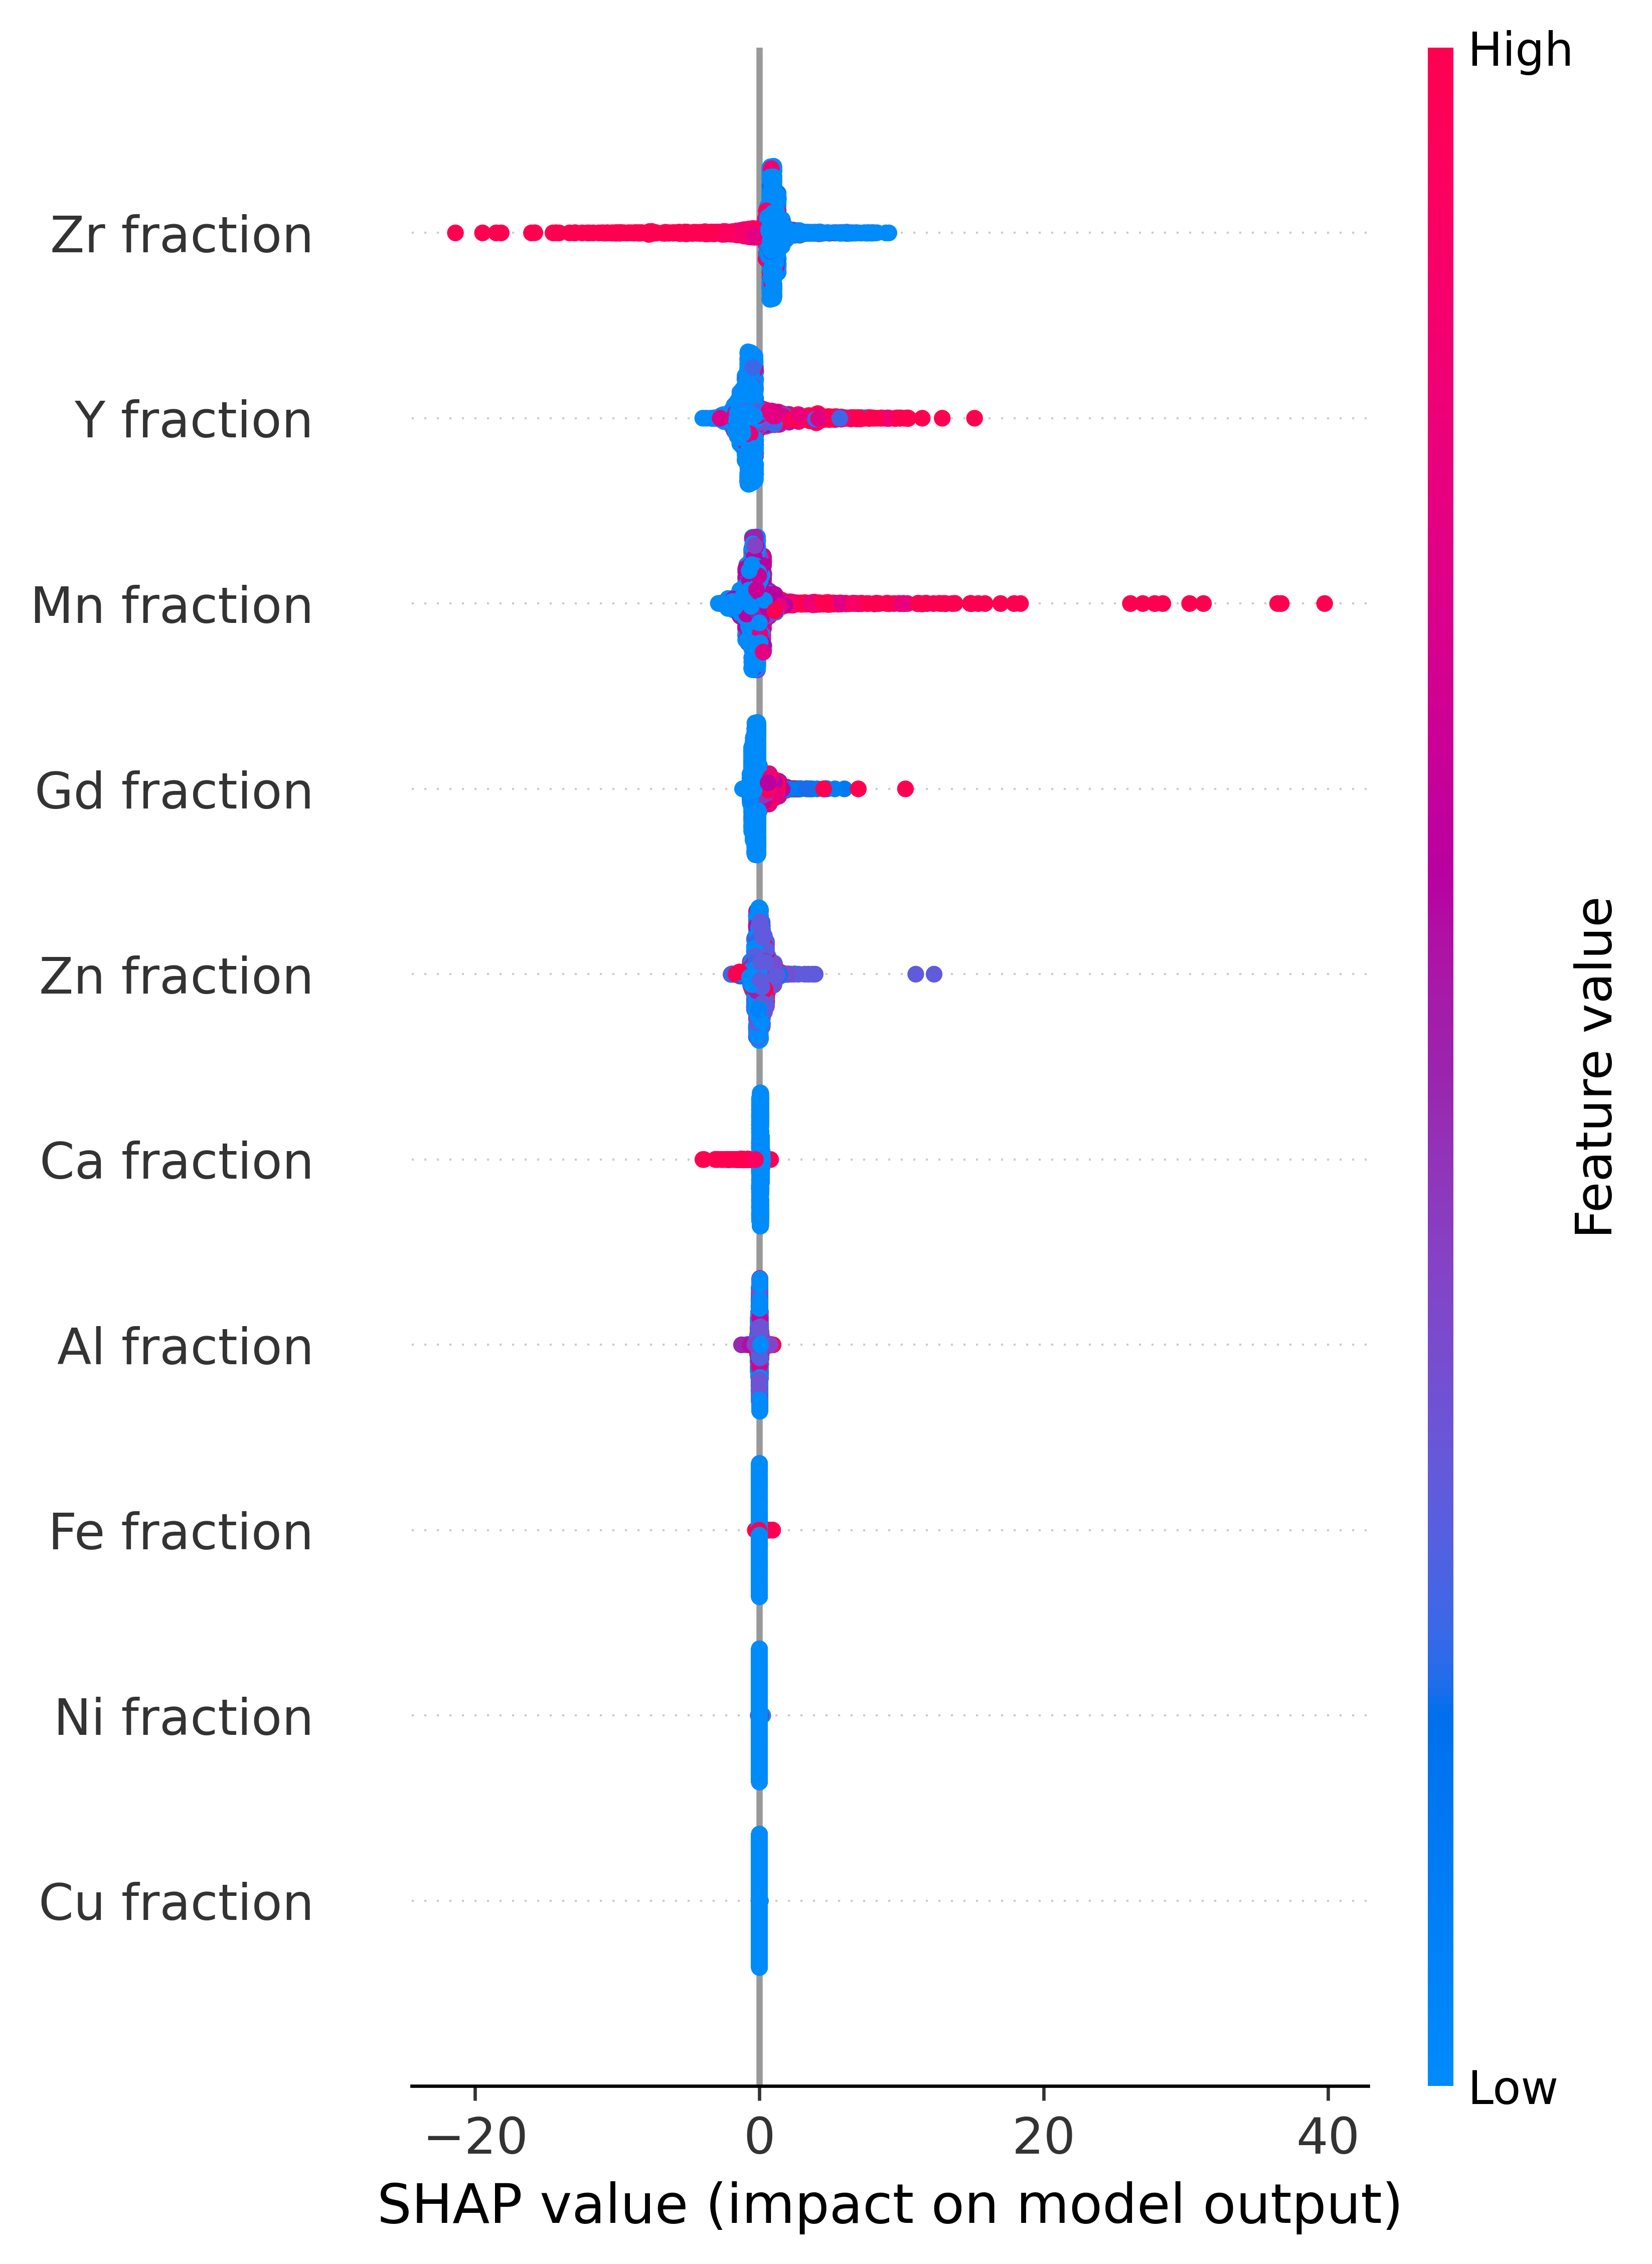

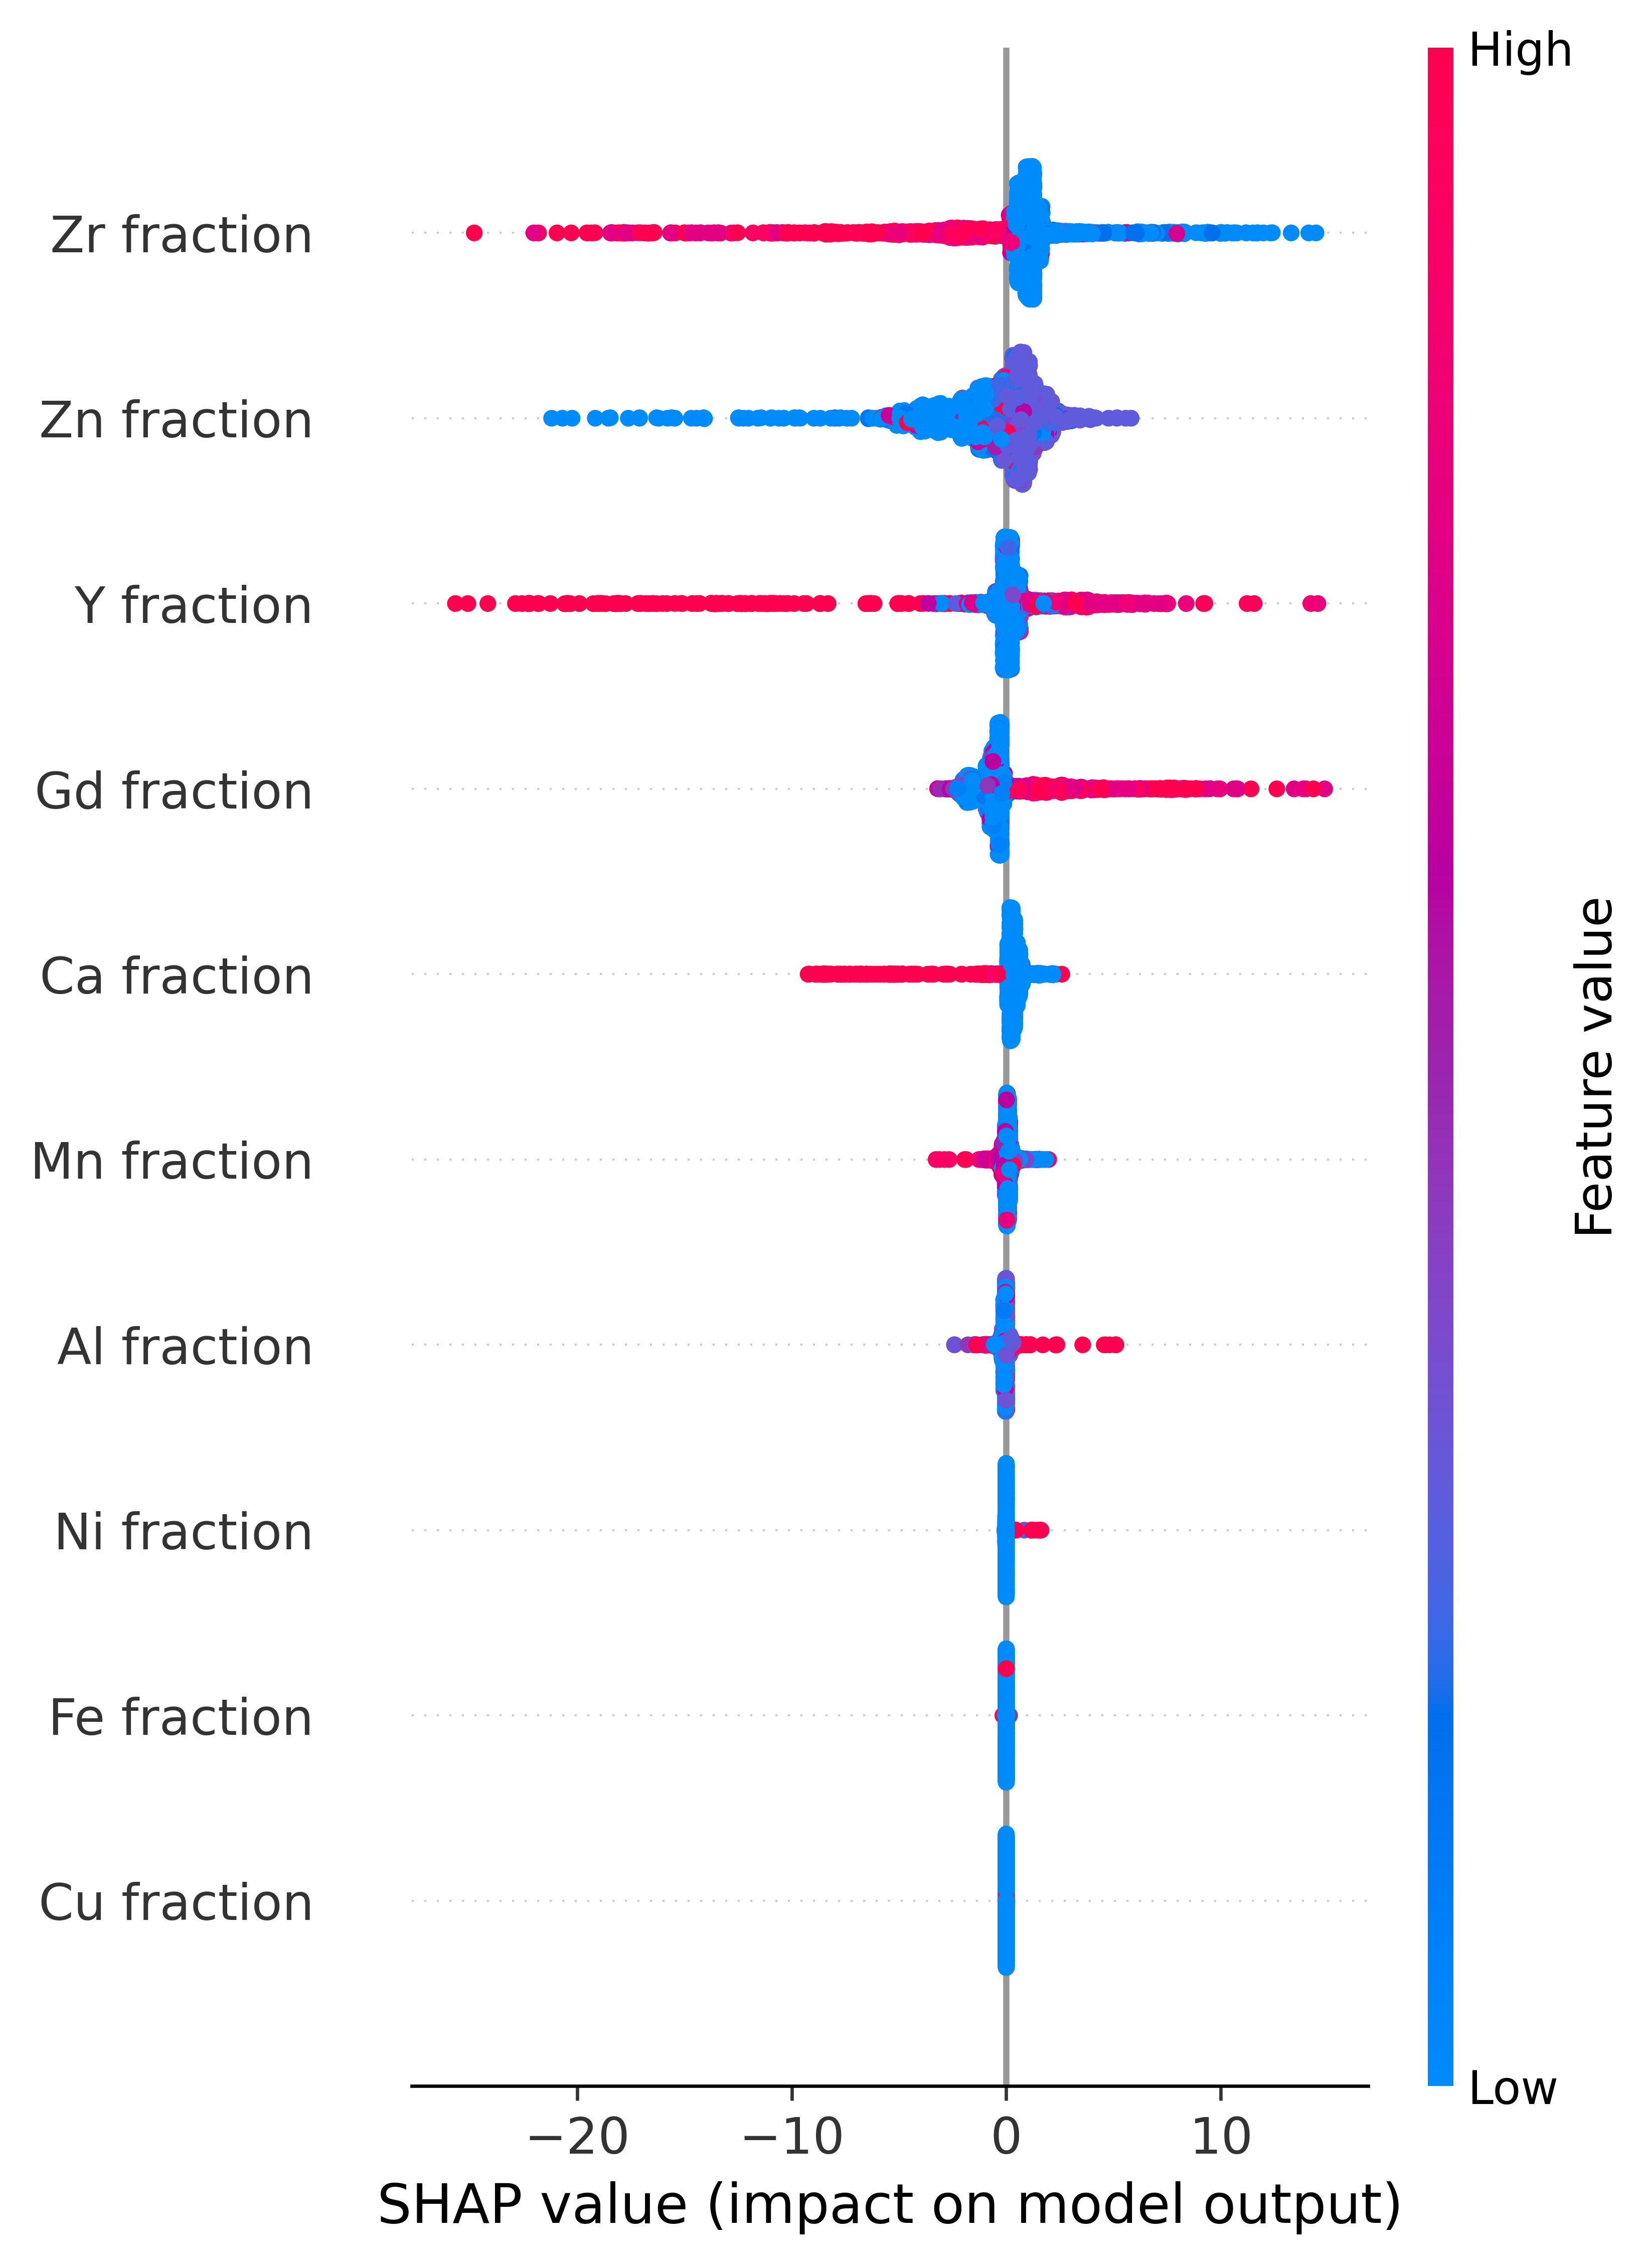

Summary plot saved to summary_plot.svg


<Figure size 640x480 with 0 Axes>

In [20]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

# 指定特征列表及其顺序
features_to_plot = ['Y fraction','Gd fraction','Al fraction','Ca fraction','Zn fraction','Mn fraction','Zr fraction','Fe fraction','Ni fraction','Cu fraction'] # 示例特征列表，请替换为实际特征和顺序
target_name=['qf','kl']
for target in target_name:
    # 从最终输出的文件中读取数据
    original_df = pd.read_excel(f'index/{target}_shap_combined.xlsx', sheet_name='Original_Values')
    shap_df = pd.read_excel(f'index/{target}_shap_combined.xlsx', sheet_name='SHAP_Values')
    
    # 提取指定特征的原始值和SHAP值
    x = original_df[features_to_plot].values
    
    shap_values = shap_df[[f"{feature}" for feature in features_to_plot]].values
    # 绘制summary_plot图（散点图）
    shap.summary_plot(shap_values, x, feature_names=features_to_plot, show=False, plot_type='dot')
    plt.gcf().set_dpi(600)  # 设置dpi

    # 保存summary_plot图
    # 绘制彩色的shap summary plot
    plt.gcf().set_size_inches(5, 8)  # 设置图像大小
   
    plt.xticks(fontsize=12)  # 设置x轴标签字体大小
    plt.yticks(fontsize=12)  # 设置y轴标签字体大小
    plt.show()
    
    # 显示图像
    plt.savefig(f'General_model_{target}_summary_plot.svg')
print("Summary plot saved to summary_plot.svg")


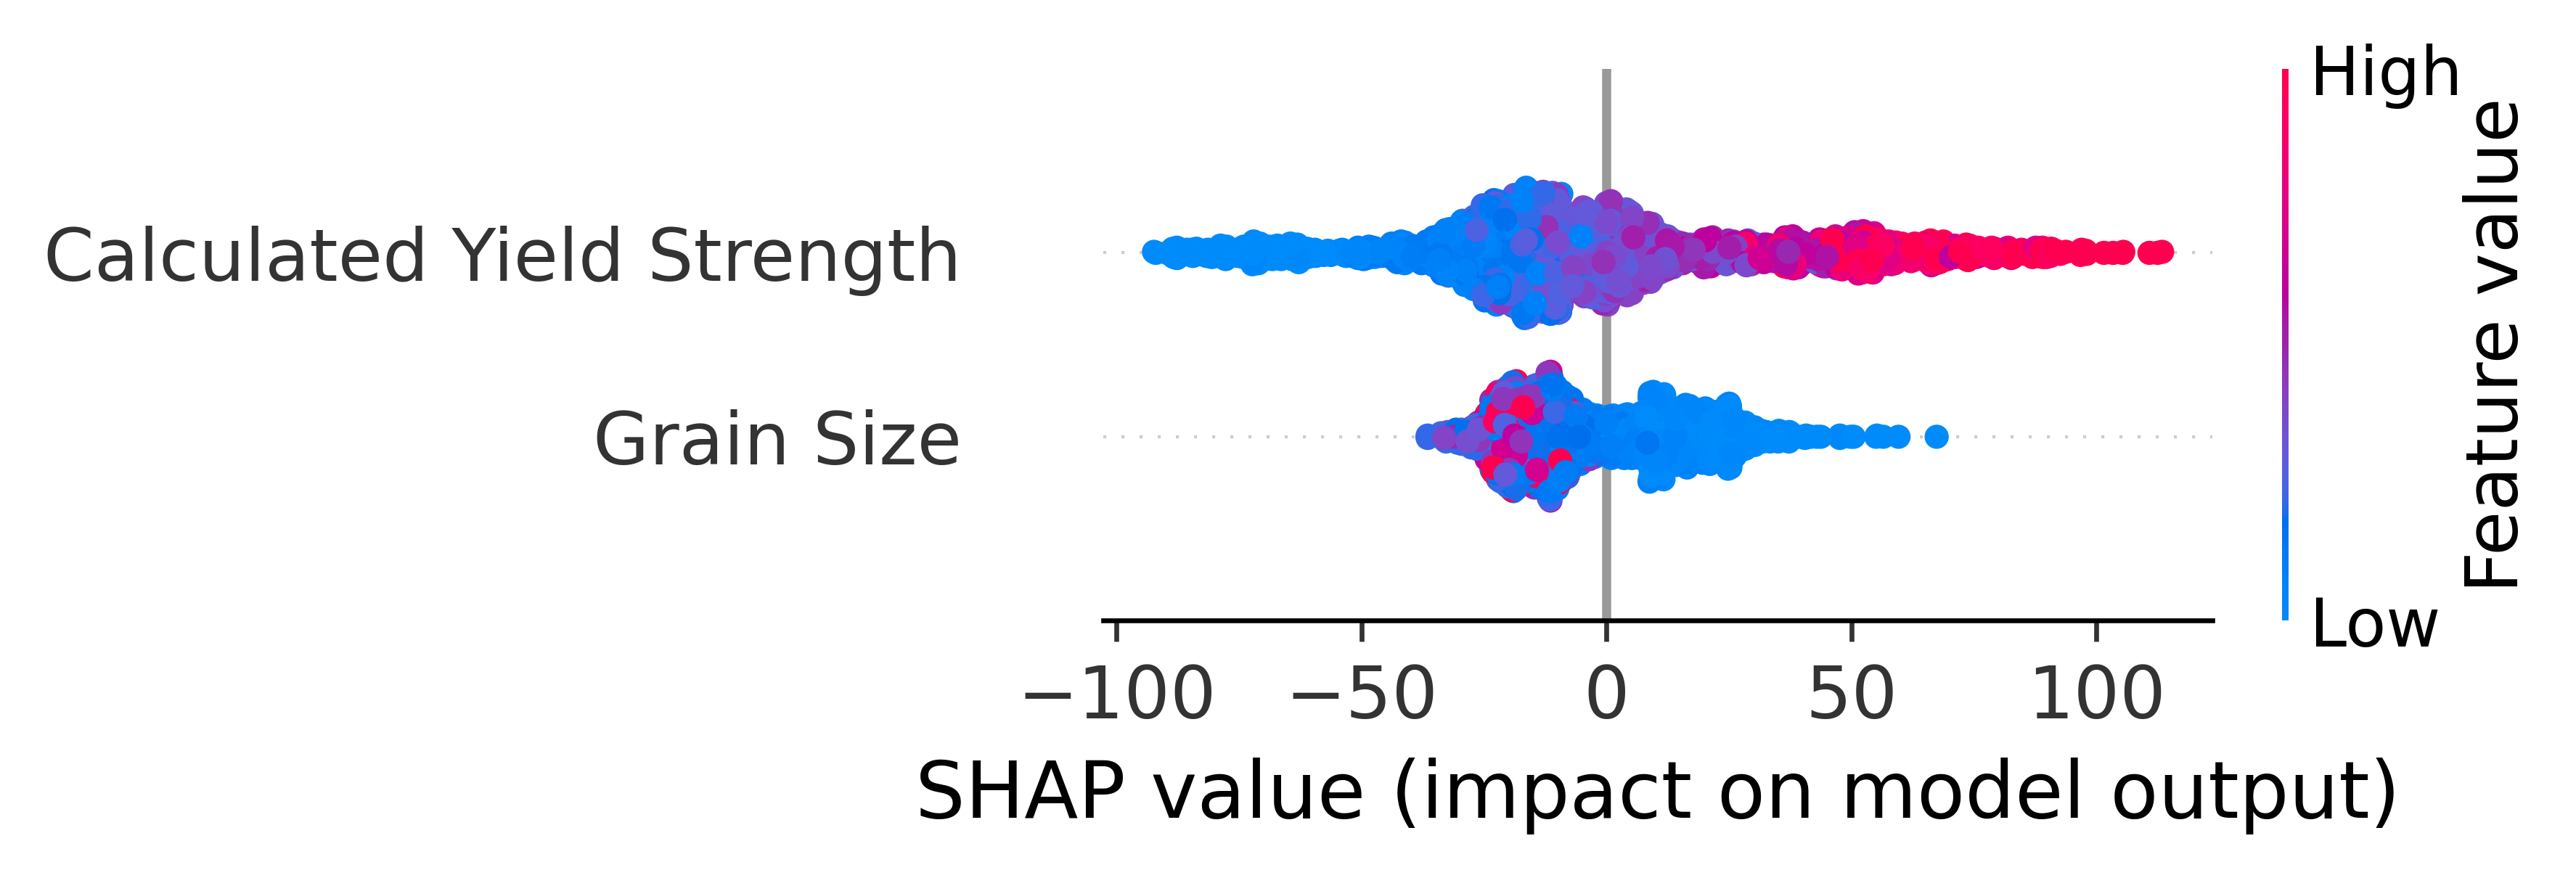

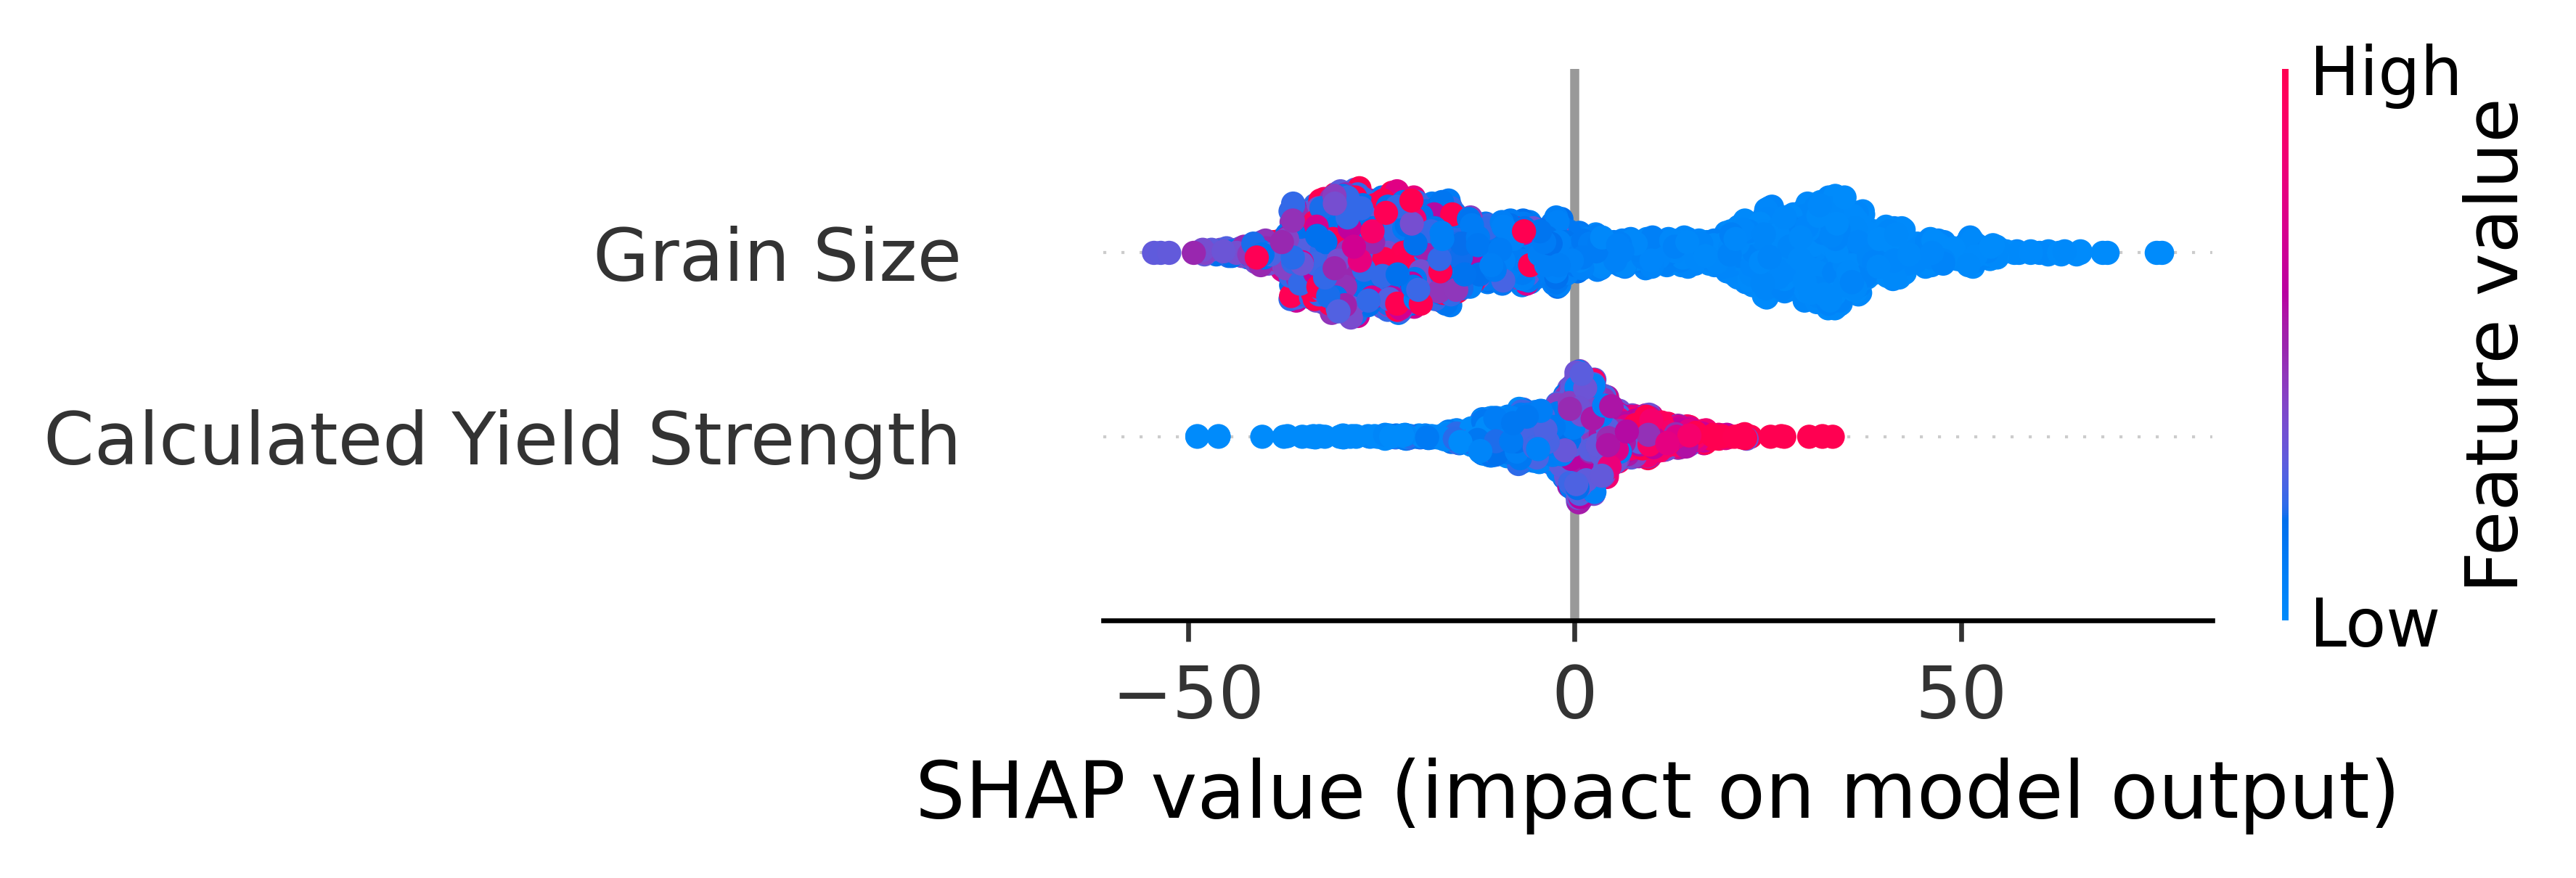

Summary plot saved to summary_plot.svg


<Figure size 640x480 with 0 Axes>

In [28]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

# 指定特征列表及其顺序
features_to_plot = ['Grain Size','Calculated Yield Strength'] # 示例特征列表，请替换为实际特征和顺序
target_name=['qf','kl']
for target in target_name:
    # 从最终输出的文件中读取数据
    original_df = pd.read_excel(f'index/{target}_shap_combined.xlsx', sheet_name='Original_Values')
    shap_df = pd.read_excel(f'index/{target}_shap_combined.xlsx', sheet_name='SHAP_Values')
    
    # 提取指定特征的原始值和SHAP值
    x = original_df[features_to_plot].values
    
    shap_values = shap_df[[f"{feature}" for feature in features_to_plot]].values
    # 绘制summary_plot图（散点图）
    shap.summary_plot(shap_values, x, feature_names=features_to_plot, show=False, plot_type='dot')
    plt.gcf().set_dpi(600)  # 设置dpi

    # 保存summary_plot图
    # 绘制彩色的shap summary plot
    plt.gcf().set_size_inches(5, 2)  # 设置图像大小
   
    plt.xticks(fontsize=12)  # 设置x轴标签字体大小
    plt.yticks(fontsize=12)  # 设置y轴标签字体大小
    plt.show()
    
    # 显示图像
    plt.savefig(f'General_model_{target}_summary_plot_empirical.svg')
print("Summary plot saved to summary_plot.svg")


In [1]:
# 研究仅含有fraction的shap结果
import pandas as pd
import shap
import matplotlib.pyplot as plt

# 加载Excel文件
file_path = 'index/qf_shap.xlsx'
xls = pd.ExcelFile(file_path)

# 获取所有sheet名称
sheet_names = xls.sheet_names

# 识别包含原始值和shap值的sheet
original_sheets = [sheet for sheet in sheet_names if 'original' in sheet]
shap_sheets = [sheet for sheet in sheet_names if 'shap' in sheet]

# 初始化存储dataframe的列表
original_dfs = []
shap_dfs = []

# 读取每个原始值和shap值的sheet
for sheet in original_sheets:
    df = pd.read_excel(xls, sheet)
    df['Model'] = sheet  # 添加一列用于识别模型
    original_dfs.append(df)

for sheet in shap_sheets:
    df = pd.read_excel(xls, sheet)
    df['Model'] = sheet  # 添加一列用于识别模型
    shap_dfs.append(df)

# 将所有原始值和shap值的数据帧连接起来
original_data = pd.concat(original_dfs, ignore_index=True)
shap_data = pd.concat(shap_dfs, ignore_index=True)

# 合并原始数据和shap数据
final_data = pd.merge(original_data, shap_data, suffixes=('_original', '_shap'))

# # 转换shap数据为数值类型，非数值类型将被转换为NaN
for col in final_data.columns:
    if col.endswith('_shap'):
        final_data[col] = pd.to_numeric(final_data[col], errors='coerce')

# 准备用于绘图的数据
X = final_data[[col for col in final_data.columns if col.endswith('_original')]]
shap_values = final_data[[col for col in final_data.columns if col.endswith('_shap')]]

# 提取特征名称（去掉'_original'）
original_feature_names = [col.replace('_original', '') for col in X.columns]
X.columns = original_feature_names
shap_values.columns = original_feature_names

# 筛选出包含"fraction"的特征
fraction_features = ['Y fraction','Gd fraction','Al fraction','Ca fraction','Zn fraction','Mn fraction','Zr fraction','Fe fraction','Ni fraction','Cu fraction']

# 计算每个特征的平均绝对SHAP值
mean_abs_shap_values = shap_values[fraction_features].abs().mean().sort_values(ascending=False)

# 选择前10个重要的fraction特征
top_fraction_features = mean_abs_shap_values.index[:10]

# 选择用于绘图的数据
X_top_fraction = X[top_fraction_features]
shap_values_top_fraction = shap_values[top_fraction_features]

plt.gcf().set_dpi(600)  # 设置dpi

# 绘制彩色的shap summary plot
shap.summary_plot(shap_values_top_fraction.values, X_top_fraction.values, show=False, feature_names=top_fraction_features,)
plt.gcf().set_size_inches(5, 8)  # 设置图像大小

plt.xticks(fontsize=12)  # 设置x轴标签字体大小
plt.yticks(fontsize=12)  # 设置y轴标签字体大小

# 显示图像
plt.show()

C:\Users\acer-pc\AppData\Local\Temp\ipykernel_24212\972886386.py:37: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  final_data = pd.merge(original_data, shap_data, suffixes=('_original', '_shap'))


KeyError: "None of [Index(['Y fraction', 'Gd fraction', 'Al fraction', 'Ca fraction',\n       'Zn fraction', 'Mn fraction', 'Zr fraction', 'Fe fraction',\n       'Ni fraction', 'Cu fraction'],\n      dtype='object')] are in the [columns]"

In [3]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

# 指定想要研究的特征列表和顺序
features_to_plot = ['Y fraction', 'Gd fraction']  # 示例特征列表，请替换为实际特征
models = ["rf", "xgboost"]
indices = range(1, 6)

# 初始化一个新的Excel writer
writer = pd.ExcelWriter('shap_values.xlsx', engine='openpyxl')

# 读取所有的模型数据并绘制summary_plot
for model in models:
    for index in indices:
        original_sheet_name = f"qf_{model}_original_{index}"
        shap_sheet_name = f"qf_{model}_shap_{index}"

        # 读取数据
        original_df = pd.read_excel('index/qf_shap.xlsx', sheet_name=original_sheet_name)
        shap_df = pd.read_excel('index/qf_shap.xlsx', sheet_name=shap_sheet_name)

        # 选择特定特征并按照指定顺序绘制summary_plot
        shap_values = shap_df[features_to_plot].values
        original_values = original_df[features_to_plot].values

        # 绘制summary_plot
        shap.summary_plot(shap_values, features=original_values, feature_names=features_to_plot, show=False)
        plt.title(f"SHAP Summary Plot - {model.upper()} {index}")
        plt.savefig(f"summary_plot_{model}_{index}.png")
        plt.clf()

        # 保存原始值和shap值到新的sheet中
        combined_df = pd.DataFrame(original_values, columns=features_to_plot)
        for feature in features_to_plot:
            combined_df[f"{feature}_shap"] = shap_df[feature].values
        combined_df.to_excel(writer, sheet_name=f"{model}_{index}", index=False)

# 保存Excel文件
# writer.save()
print("Summary plots saved and SHAP values written to shap_values.xlsx")


Summary plots saved and SHAP values written to shap_values.xlsx


<Figure size 800x230 with 0 Axes>

In [0]:
# 研究仅含有fraction的shap结果
import pandas as pd
import shap
import matplotlib.pyplot as plt

# 加载Excel文件
file_path = 'results/qf_weighted_pre.xlsx'
xls = pd.ExcelFile(file_path)

# 获取所有sheet名称
sheet_names = xls.sheet_names

# 识别包含原始值和shap值的sheet
original_sheets = [sheet for sheet in sheet_names if 'original' in sheet]
shap_sheets = [sheet for sheet in sheet_names if 'shap' in sheet]

# 初始化存储dataframe的列表
original_dfs = []
shap_dfs = []

# 读取每个原始值和shap值的sheet
for sheet in original_sheets:
    df = pd.read_excel(xls, sheet)
    df['Model'] = sheet  # 添加一列用于识别模型
    original_dfs.append(df)

for sheet in shap_sheets:
    df = pd.read_excel(xls, sheet)
    df['Model'] = sheet  # 添加一列用于识别模型
    shap_dfs.append(df)

# 将所有原始值和shap值的数据帧连接起来
original_data = pd.concat(original_dfs, ignore_index=True)
shap_data = pd.concat(shap_dfs, ignore_index=True)

# 合并原始数据和shap数据
final_data = pd.merge(original_data, shap_data, on='Unnamed: 0', suffixes=('_original', '_shap'))

# 转换shap数据为数值类型，非数值类型将被转换为NaN
for col in final_data.columns:
    if col.endswith('_shap'):
        final_data[col] = pd.to_numeric(final_data[col], errors='coerce')

# 准备用于绘图的数据
X = final_data[[col for col in final_data.columns if col.endswith('_original')]]
shap_values = final_data[[col for col in final_data.columns if col.endswith('_shap')]]

# 提取特征名称（去掉'_original'）
original_feature_names = [col.replace('_original', '') for col in X.columns]
X.columns = original_feature_names
shap_values.columns = original_feature_names

# 筛选出包含"fraction"的特征
fraction_features = [col for col in original_feature_names if 'fraction' in col]

# 计算每个特征的平均绝对SHAP值
mean_abs_shap_values = shap_values[fraction_features].abs().mean().sort_values(ascending=False)

# 选择前10个重要的fraction特征
top_fraction_features = mean_abs_shap_values.index[:10]

# 选择用于绘图的数据
X_top_fraction = X[top_fraction_features]
shap_values_top_fraction = shap_values[top_fraction_features]

plt.gcf().set_dpi(600)  # 设置dpi

# 绘制彩色的shap summary plot
shap.summary_plot(shap_values_top_fraction.values, X_top_fraction.values, show=False, feature_names=top_fraction_features,)
plt.gcf().set_size_inches(5, 8)  # 设置图像大小

plt.xticks(fontsize=12)  # 设置x轴标签字体大小
plt.yticks(fontsize=12)  # 设置y轴标签字体大小

# 显示图像
plt.show()

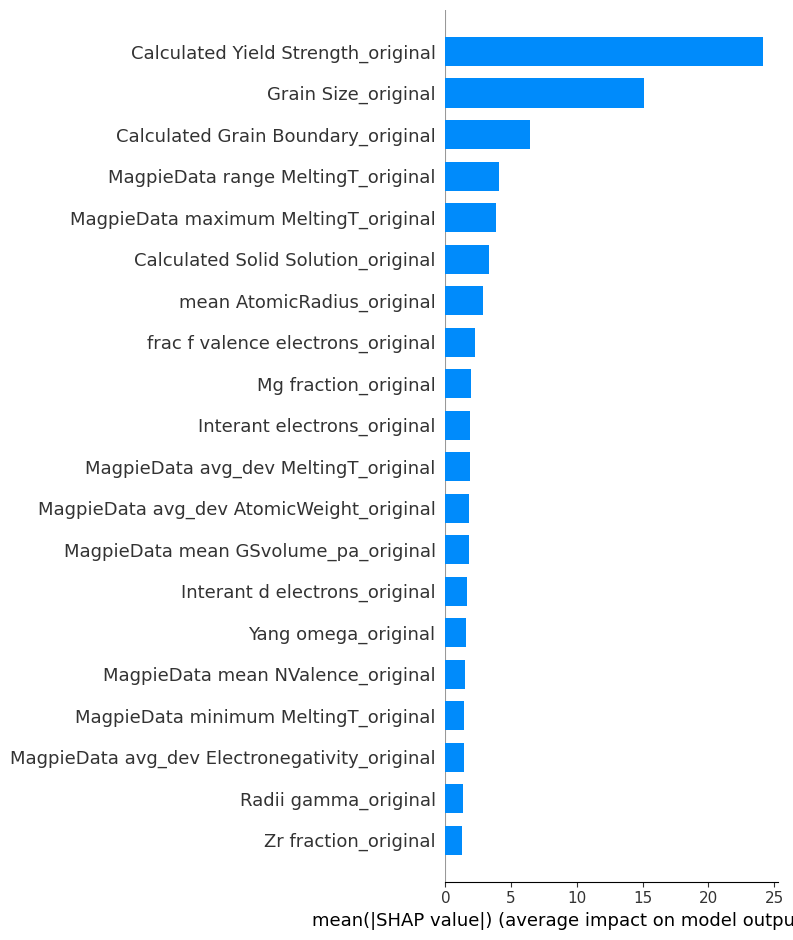

In [4]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

# 加载Excel文件
file_path = 'results/qf_weighted_pre.xlsx'
xls = pd.ExcelFile(file_path)

# 获取所有sheet名称
sheet_names = xls.sheet_names

# 识别包含原始值和shap值的sheet
original_sheets = [sheet for sheet in sheet_names if 'original' in sheet]
shap_sheets = [sheet for sheet in sheet_names if 'shap' in sheet]

# 初始化存储dataframe的列表
original_dfs = []
shap_dfs = []

# 读取每个原始值和shap值的sheet
for sheet in original_sheets:
    df = pd.read_excel(xls, sheet)
    df['Model'] = sheet  # 添加一列用于识别模型
    original_dfs.append(df)

for sheet in shap_sheets:
    df = pd.read_excel(xls, sheet)
    df['Model'] = sheet  # 添加一列用于识别模型
    shap_dfs.append(df)

# 将所有原始值和shap值的数据帧连接起来
original_data = pd.concat(original_dfs, ignore_index=True)
shap_data = pd.concat(shap_dfs, ignore_index=True)

# 合并原始数据和shap数据
final_data = pd.merge(original_data, shap_data, on='Unnamed: 0', suffixes=('_original', '_shap'))

# 转换shap数据为数值类型，非数值类型将被转换为NaN
for col in final_data.columns:
    if col.endswith('_shap'):
        final_data[col] = pd.to_numeric(final_data[col], errors='coerce')

# 准备用于绘图的数据
X = final_data[[col for col in final_data.columns if col.endswith('_original')]]
shap_values = final_data[[col for col in final_data.columns if col.endswith('_shap')]]

# 计算每个特征的平均绝对SHAP值
mean_abs_shap_values = shap_values.abs().mean().sort_values(ascending=False)

# 选择前20个重要特征
top_features = mean_abs_shap_values.index[:20]
top_feature_names = [feature.replace('_shap', '_original') for feature in top_features]

# 选择用于绘图的数据
X_top = X[top_feature_names]
shap_values_top = shap_values[top_features]

# 绘制shap summary plot
shap.summary_plot(shap_values_top.values, X_top.values, feature_names=top_feature_names, plot_type='bar')

plt.show()


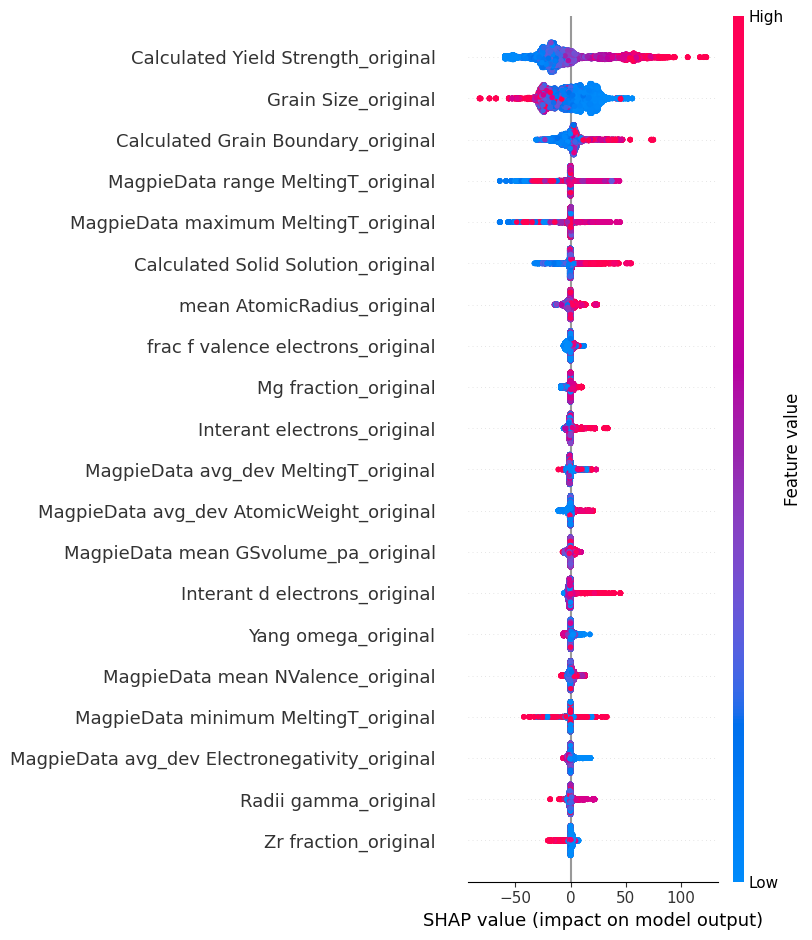

In [5]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

# 加载Excel文件
file_path = 'results/qf_weighted_pre.xlsx'
xls = pd.ExcelFile(file_path)

# 获取所有sheet名称
sheet_names = xls.sheet_names

# 识别包含原始值和shap值的sheet
original_sheets = [sheet for sheet in sheet_names if 'original' in sheet]
shap_sheets = [sheet for sheet in sheet_names if 'shap' in sheet]

# 初始化存储dataframe的列表
original_dfs = []
shap_dfs = []

# 读取每个原始值和shap值的sheet
for sheet in original_sheets:
    df = pd.read_excel(xls, sheet)
    df['Model'] = sheet  # 添加一列用于识别模型
    original_dfs.append(df)

for sheet in shap_sheets:
    df = pd.read_excel(xls, sheet)
    df['Model'] = sheet  # 添加一列用于识别模型
    shap_dfs.append(df)

# 将所有原始值和shap值的数据帧连接起来
original_data = pd.concat(original_dfs, ignore_index=True)
shap_data = pd.concat(shap_dfs, ignore_index=True)

# 合并原始数据和shap数据
final_data = pd.merge(original_data, shap_data, on='Unnamed: 0', suffixes=('_original', '_shap'))

# 转换shap数据为数值类型，非数值类型将被转换为NaN
for col in final_data.columns:
    if col.endswith('_shap'):
        final_data[col] = pd.to_numeric(final_data[col], errors='coerce')

# 准备用于绘图的数据
X = final_data[[col for col in final_data.columns if col.endswith('_original')]]
shap_values = final_data[[col for col in final_data.columns if col.endswith('_shap')]]

# 计算每个特征的平均绝对SHAP值
mean_abs_shap_values = shap_values.abs().mean().sort_values(ascending=False)

# 选择前20个重要特征
top_features = mean_abs_shap_values.index[:20]
top_feature_names = [feature.replace('_shap', '_original') for feature in top_features]

# 选择用于绘图的数据
X_top = X[top_feature_names]
shap_values_top = shap_values[top_features]

# 绘制彩色的shap summary plot
shap.summary_plot(shap_values_top.values, X_top.values, feature_names=top_feature_names)

plt.show()


In [ ]:
#　研究制定特征的shap结果
import pandas as pd
import shap
import matplotlib.pyplot as plt

# 加载Excel文件
file_path = '你的文件路径/qf_weighted_pre.xlsx'
xls = pd.ExcelFile(file_path)

# 获取所有sheet名称
sheet_names = xls.sheet_names

# 识别包含原始值和shap值的sheet
original_sheets = [sheet for sheet in sheet_names if 'original' in sheet]
shap_sheets = [sheet for sheet in sheet_names if 'shap' in sheet]

# 初始化存储dataframe的列表
original_dfs = []
shap_dfs = []

# 读取每个原始值和shap值的sheet
for sheet in original_sheets:
    df = pd.read_excel(xls, sheet)
    df['Model'] = sheet  # 添加一列用于识别模型
    original_dfs.append(df)

for sheet in shap_sheets:
    df = pd.read_excel(xls, sheet)
    df['Model'] = sheet  # 添加一列用于识别模型
    shap_dfs.append(df)

# 将所有原始值和shap值的数据帧连接起来
original_data = pd.concat(original_dfs, ignore_index=True)
shap_data = pd.concat(shap_dfs, ignore_index=True)

# 合并原始数据和shap数据
final_data = pd.merge(original_data, shap_data, on='Unnamed: 0', suffixes=('_original', '_shap'))

# 转换shap数据为数值类型，非数值类型将被转换为NaN
for col in final_data.columns:
    if col.endswith('_shap'):
        final_data[col] = pd.to_numeric(final_data[col], errors='coerce')

# 准备用于绘图的数据
X = final_data[[col for col in final_data.columns if col.endswith('_original')]]
shap_values = final_data[[col for col in final_data.columns if col.endswith('_shap')]]

# 提取特征名称（去掉'_original'）
original_feature_names = [col.replace('_original', '') for col in X.columns]
X.columns = original_feature_names
shap_values.columns = original_feature_names

# 计算每个特征的平均绝对SHAP值
mean_abs_shap_values = shap_values.abs().mean().sort_values(ascending=False)

# 用户指定的特征列表
specified_features = ['特征1', '特征2', '特征3']  # 替换为你要展示的特征名称

# 过滤出指定的特征
X_specified = X[specified_features]
shap_values_specified = shap_values[specified_features]

# 绘制彩色的shap summary plot
shap.summary_plot(shap_values_specified.values, X_specified.values, feature_names=specified_features)

plt.show()


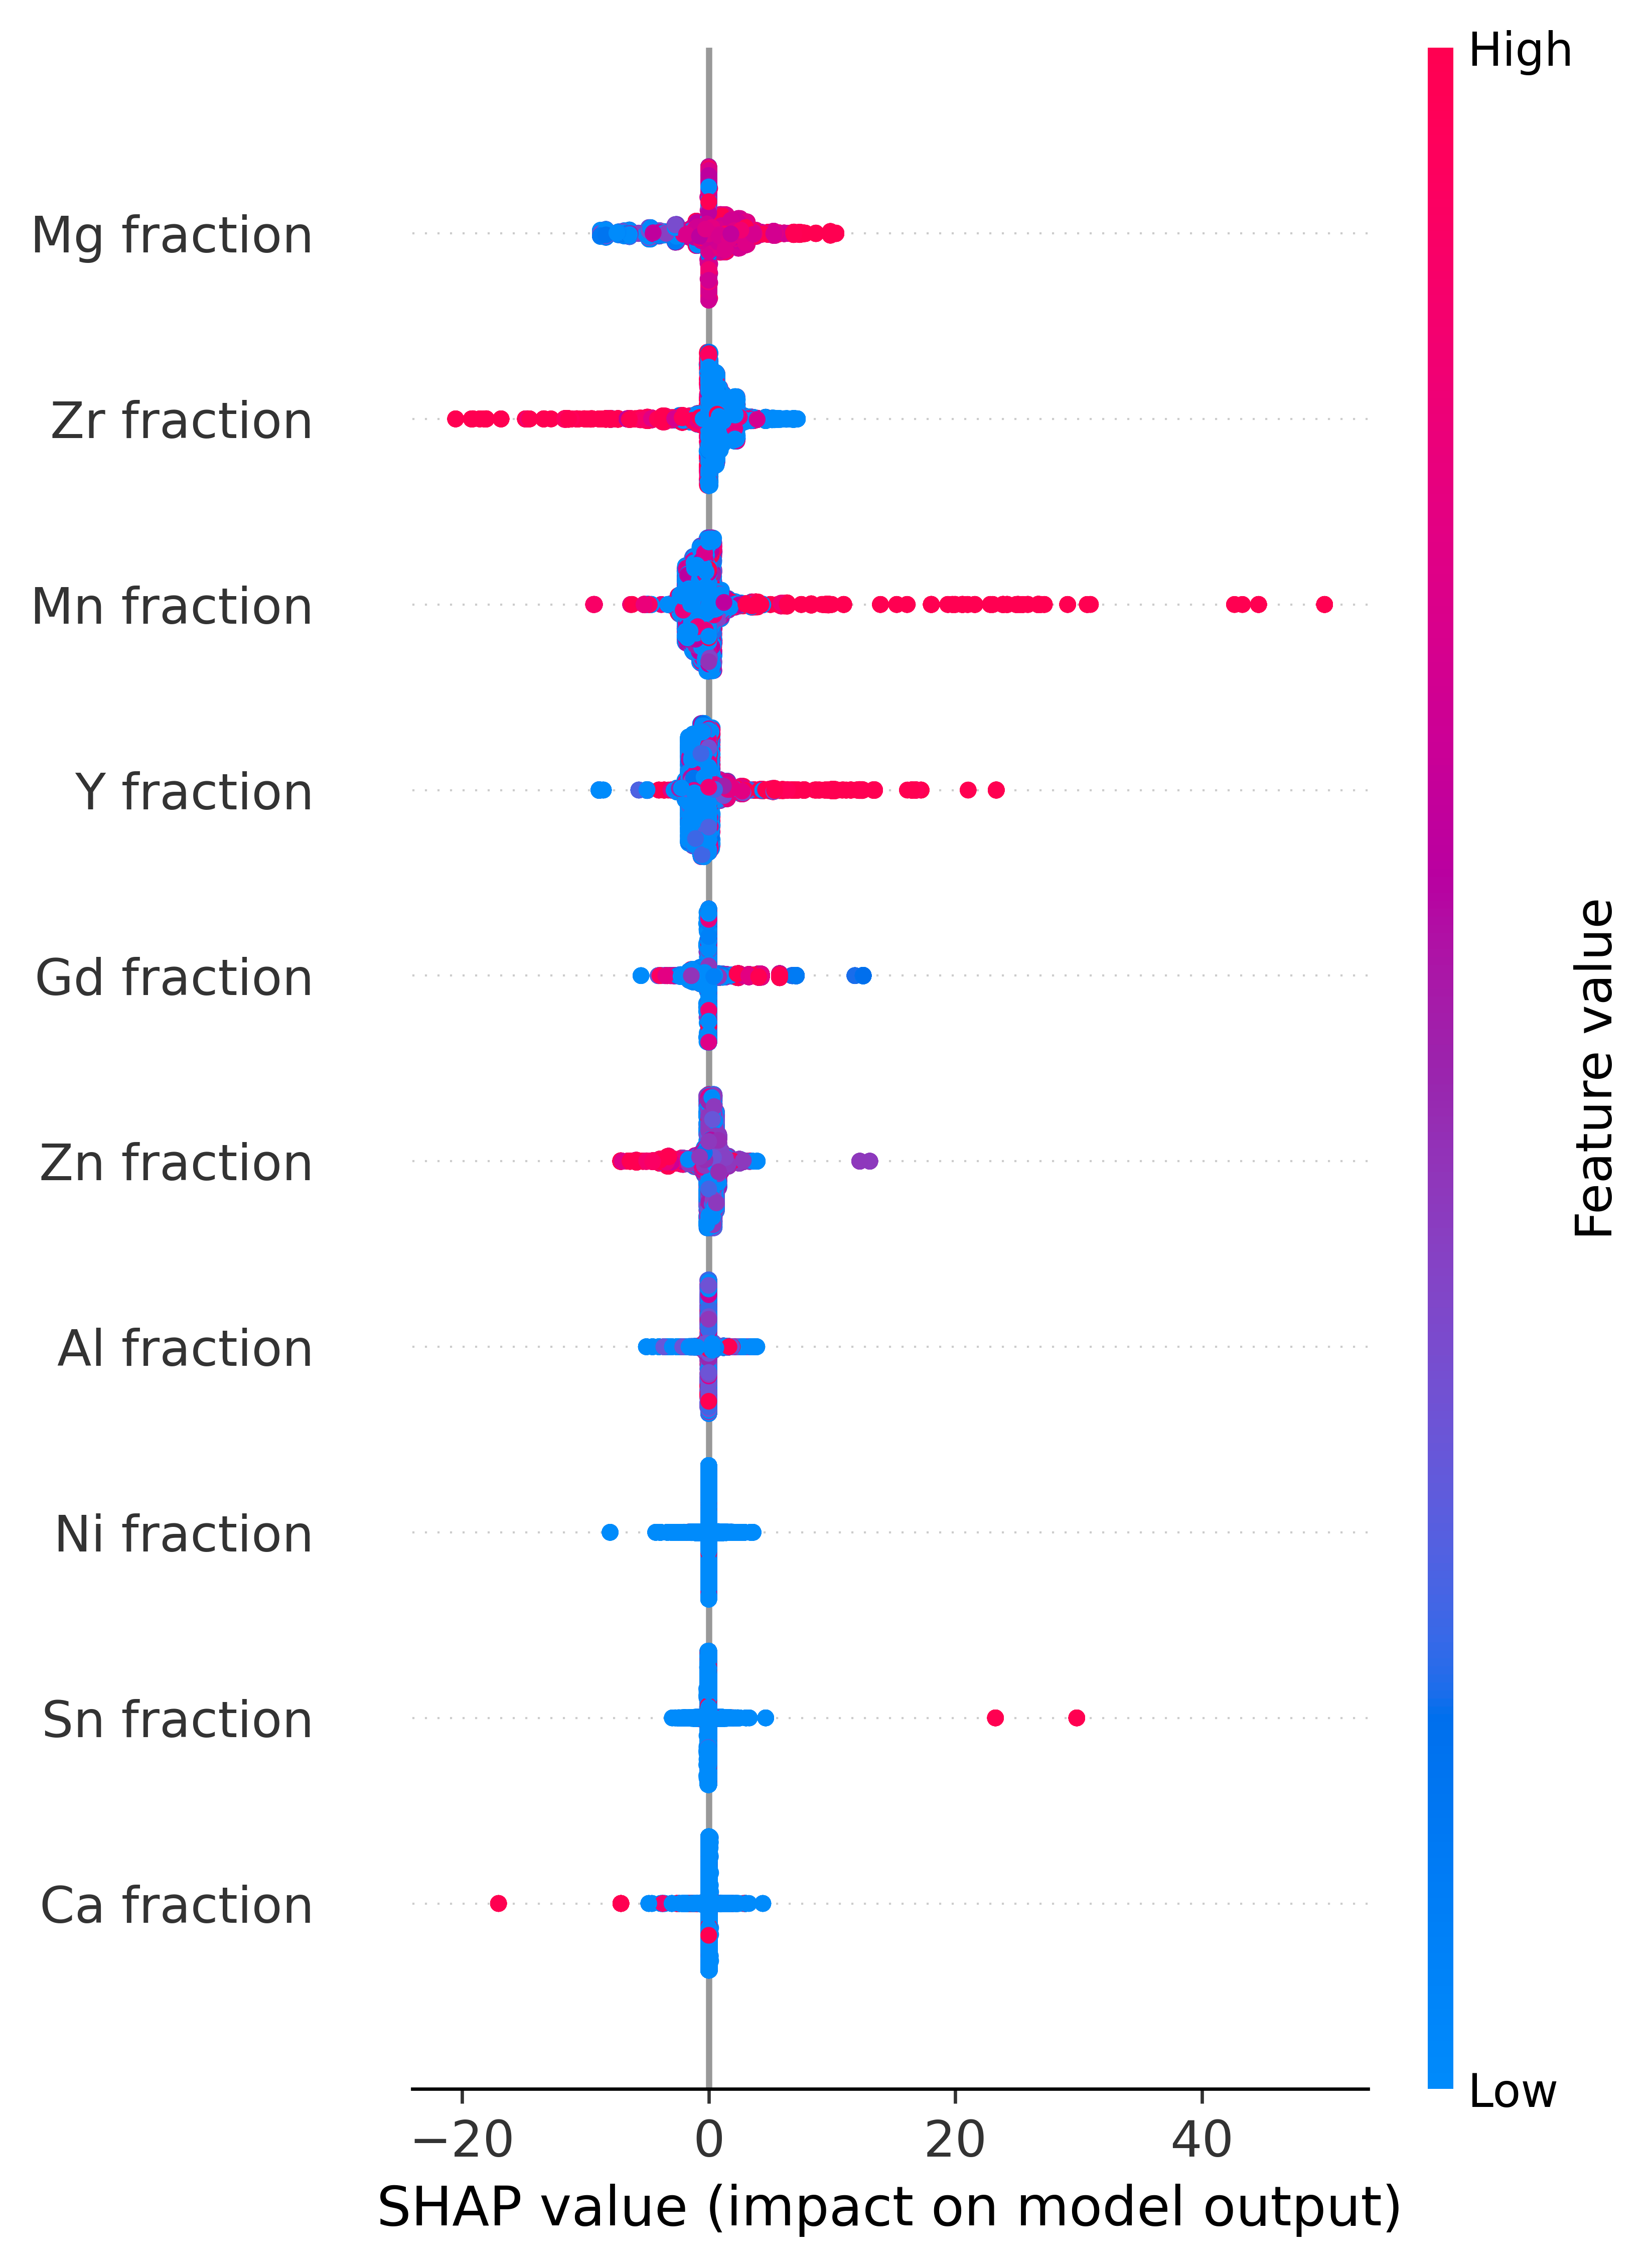

In [23]:
# 研究仅含有fraction的shap结果
import pandas as pd
import shap
import matplotlib.pyplot as plt

# 加载Excel文件
file_path = 'results/qf_weighted_pre.xlsx'
xls = pd.ExcelFile(file_path)

# 获取所有sheet名称
sheet_names = xls.sheet_names

# 识别包含原始值和shap值的sheet
original_sheets = [sheet for sheet in sheet_names if 'original' in sheet]
shap_sheets = [sheet for sheet in sheet_names if 'shap' in sheet]

# 初始化存储dataframe的列表
original_dfs = []
shap_dfs = []

# 读取每个原始值和shap值的sheet
for sheet in original_sheets:
    df = pd.read_excel(xls, sheet)
    df['Model'] = sheet  # 添加一列用于识别模型
    original_dfs.append(df)

for sheet in shap_sheets:
    df = pd.read_excel(xls, sheet)
    df['Model'] = sheet  # 添加一列用于识别模型
    shap_dfs.append(df)

# 将所有原始值和shap值的数据帧连接起来
original_data = pd.concat(original_dfs, ignore_index=True)
shap_data = pd.concat(shap_dfs, ignore_index=True)

# 合并原始数据和shap数据
final_data = pd.merge(original_data, shap_data, on='Unnamed: 0', suffixes=('_original', '_shap'))

# 转换shap数据为数值类型，非数值类型将被转换为NaN
for col in final_data.columns:
    if col.endswith('_shap'):
        final_data[col] = pd.to_numeric(final_data[col], errors='coerce')

# 准备用于绘图的数据
X = final_data[[col for col in final_data.columns if col.endswith('_original')]]
shap_values = final_data[[col for col in final_data.columns if col.endswith('_shap')]]

# 提取特征名称（去掉'_original'）
original_feature_names = [col.replace('_original', '') for col in X.columns]
X.columns = original_feature_names
shap_values.columns = original_feature_names

# 筛选出包含"fraction"的特征
fraction_features = [col for col in original_feature_names if 'fraction' in col]

# 计算每个特征的平均绝对SHAP值
mean_abs_shap_values = shap_values[fraction_features].abs().mean().sort_values(ascending=False)

# 选择前10个重要的fraction特征
top_fraction_features = mean_abs_shap_values.index[:10]

# 选择用于绘图的数据
X_top_fraction = X[top_fraction_features]
shap_values_top_fraction = shap_values[top_fraction_features]

plt.gcf().set_dpi(600)  # 设置dpi

# 绘制彩色的shap summary plot
shap.summary_plot(shap_values_top_fraction.values, X_top_fraction.values, show=False, feature_names=top_fraction_features,)
plt.gcf().set_size_inches(5, 8)  # 设置图像大小

plt.xticks(fontsize=12)  # 设置x轴标签字体大小
plt.yticks(fontsize=12)  # 设置y轴标签字体大小

# 显示图像
plt.show()